# San Francisco-i bűnözési elemzés
Refaktorált és kibővített elemzés a San Francisco-i bűnözési adatokról.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap, MarkerCluster
from sklearn.cluster import DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set(style="whitegrid")

## 1. fázis: Adatok betöltése és tisztítása

In [2]:
# Adatok betöltése
df = pd.read_csv('Map-Crime_Incidents-Previous_Three_Months.csv')

# 1. Az IncidntNum hiányzó értékeinek kezelése
df['IncidntNum'] = df['IncidntNum'].fillna(0).astype(int)

# 2. Konvertálás dátum/idő típusra
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M').dt.time

# 3. Adattípus-optimalizálás
df['Category'] = df['Category'].astype('category')
df['PdDistrict'] = df['PdDistrict'].astype('category')
df['DayOfWeek'] = df['DayOfWeek'].astype('category')

# Érvénytelen koordináták szűrése
df = df[(df['X'] < -120) & (df['Y'] > 30)]

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 30760 entries, 0 to 30759
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   IncidntNum  30760 non-null  int64              
 1   Category    30760 non-null  category           
 2   Descript    30760 non-null  str                
 3   DayOfWeek   30760 non-null  category           
 4   Date        30760 non-null  datetime64[us, UTC]
 5   Time        30760 non-null  object             
 6   PdDistrict  30760 non-null  category           
 7   Resolution  30760 non-null  str                
 8   Address     30760 non-null  str                
 9   X           30760 non-null  float64            
 10  Y           30760 non-null  float64            
 11  Location    30760 non-null  str                
dtypes: category(3), datetime64[us, UTC](1), float64(2), int64(1), object(1), str(4)
memory usage: 4.9+ MB


,IncidntNum,Category,Descript,DayOfWeek,Date,Time,PdDistrict,Resolution,Address,X,Y,Location
0,0,LARCENY/THEFT,GRAND THEFT FROM UNLOCKED AUTO,Sunday,2014-08-31 07:00:00+00:00,20:30:00,CENTRAL,NONE,HYDE ST / CALIFORNIA ST,-122.417393,37.790974,"(37.7909741243888, -122.417392830334)"
1,0,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Sunday,2014-08-31 07:00:00+00:00,14:30:00,CENTRAL,NONE,COLUMBUS AV / JACKSON ST,-122.404418,37.796302,"(37.7963018736036, -122.404417620748)"
2,0,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Sunday,2014-08-31 07:00:00+00:00,11:30:00,CENTRAL,NONE,SUTTER ST / STOCKTON ST,-122.406959,37.789435,"(37.7894347630337, -122.406958660602)"
3,0,DRUG/NARCOTIC,POSSESSION OF METH-AMPHETAMINE,Sunday,2014-08-31 07:00:00+00:00,17:49:00,MISSION,"ARREST, BOOKED",16TH ST / MISSION ST,-122.419672,37.765050,"(37.7650501214965, -122.419671780296)"
4,0,DRUG/NARCOTIC,POSSESSION OF COCAINE,Sunday,2014-08-31 07:00:00+00:00,18:05:00,NORTHERN,"ARREST, BOOKED",LARKIN ST / OFARRELL ST,-122.417904,37.785167,"(37.7851670875814, -122.417903977564)"


## 1. fázis: Statisztikai vizualizációk

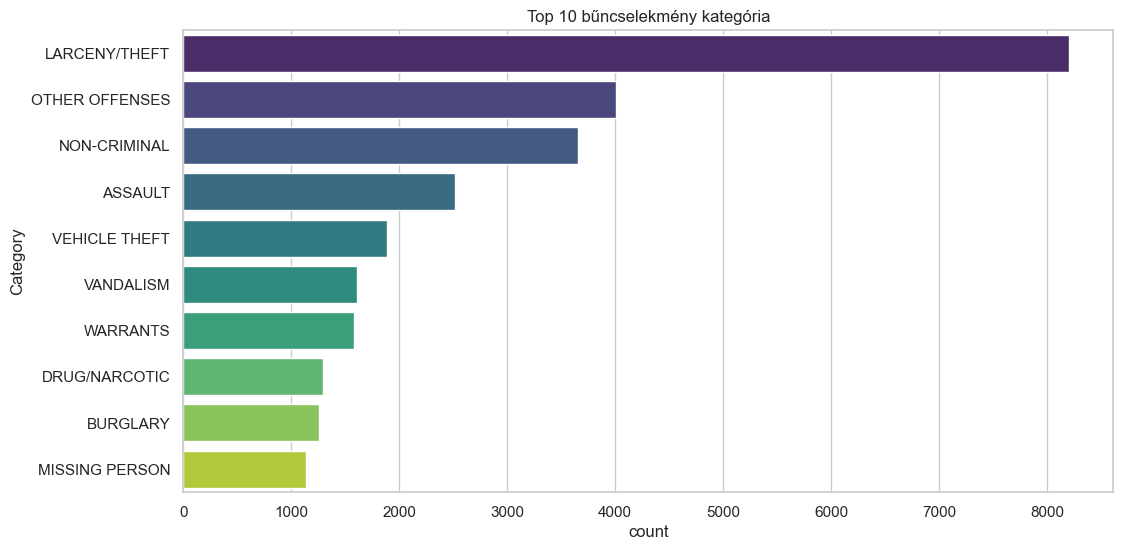

In [3]:
# Top 10 bűncselekmény kategória
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Category', order=df['Category'].value_counts().iloc[:10].index, palette='viridis')
plt.title('Top 10 bűncselekmény kategória')
plt.show()

## ÚJ: Megoldási arány elemzése (Resolution Analysis)
Vizsgáljuk meg a megoldott ('ARREST, BOOKED') és a megoldatlan ('NONE') ügyek arányát a leggyakoribb bűncselekményeknél.

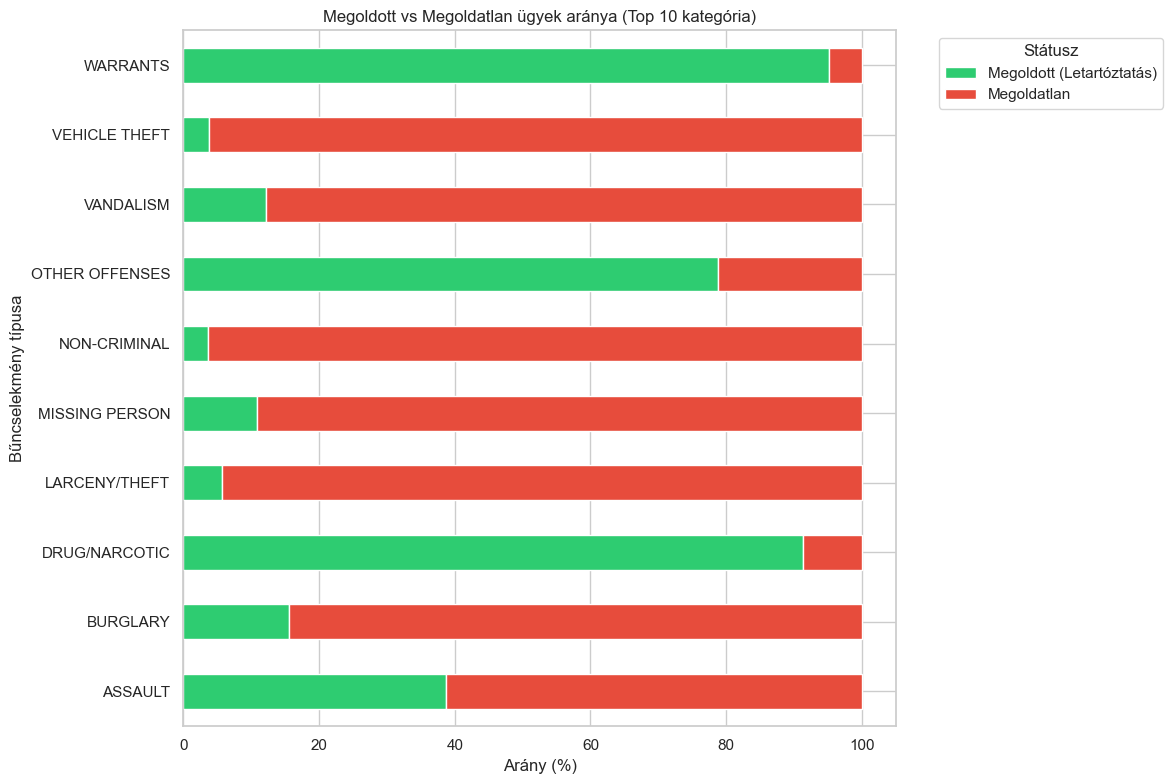

In [4]:
# Csoportosítás megoldott és megoldatlan kategóriákba
def categorize_resolution(res):
    if 'ARREST' in str(res).upper():
        return 'Megoldott (Letartóztatás)'
    elif 'NONE' in str(res).upper():
        return 'Megoldatlan'
    else:
        return 'Egyéb'

df['Resolution_Status'] = df['Resolution'].apply(categorize_resolution)

# Top 10 kategória kiválasztása
top_10_cats = df['Category'].value_counts().iloc[:10].index
df_top_10 = df[df['Category'].isin(top_10_cats)]

# Stacked bar chart készítése
resolution_counts = df_top_10.groupby(['Category', 'Resolution_Status']).size().unstack().fillna(0)
# Csak a Megoldott és Megoldatlan oszlopok arányát nézzük
resolution_counts = resolution_counts[['Megoldott (Letartóztatás)', 'Megoldatlan']]

# Arányok kiszámítása (százalékosítva)
resolution_pct = resolution_counts.div(resolution_counts.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 8))
resolution_pct.plot(kind='barh', stacked=True, color=['#2ecc71', '#e74c3c'], ax=plt.gca())
plt.title('Megoldott vs Megoldatlan ügyek aránya (Top 10 kategória)')
plt.xlabel('Arány (%)')
plt.ylabel('Bűncselekmény típusa')
plt.legend(title='Státusz', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 1. fázis: Interaktív térképes vizualizáció

In [5]:
map_df = df.sample(min(1000, len(df)))
sf_map = folium.Map(location=[37.77, -122.42], zoom_start=12)
heat_data = [[row['Y'], row['X']] for index, row in df.sample(min(2000, len(df))).iterrows()]
HeatMap(heat_data).add_to(sf_map)
marker_cluster = MarkerCluster().add_to(sf_map)
for index, row in map_df.iterrows():
    folium.Marker(location=[row['Y'], row['X']], popup=f"{row['Category']}: {row['Descript']}").add_to(marker_cluster)
sf_map

## 2. fázis: Haladó Jellemző-kinyerés (Time_of_Day)
Létrehozunk egy új 'Time_of_Day' oszlopot az órák bekategorizálásával.

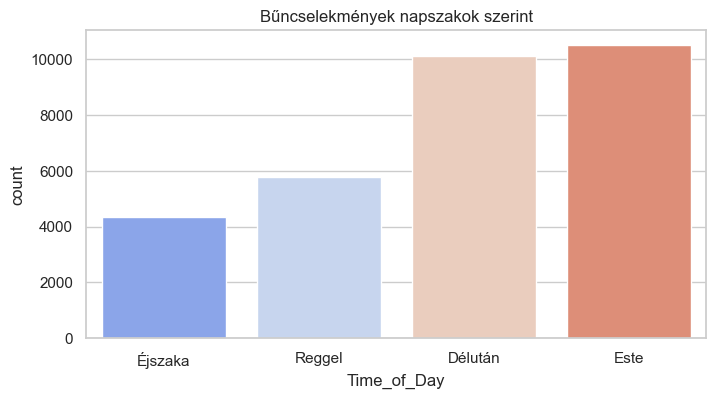

In [6]:
# Óra kinyerése
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour

# Napszakok kategorizálása (Éjszaka: 0-5, Reggel: 6-11, Délután: 12-17, Este: 18-23)
def get_time_of_day_refined(hour):
    if 0 <= hour <= 5: return 'Éjszaka'
    elif 6 <= hour <= 11: return 'Reggel'
    elif 12 <= hour <= 17: return 'Délután'
    elif 18 <= hour <= 23: return 'Este'

df['Time_of_Day'] = df['Time_of_Day'] = df['Hour'].apply(get_time_of_day_refined)

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Time_of_Day', order=['Éjszaka', 'Reggel', 'Délután', 'Este'], palette='coolwarm')
plt.title('Bűncselekmények napszakok szerint')
plt.show()

## 2. fázis: Klaszterezés és Szófelhő

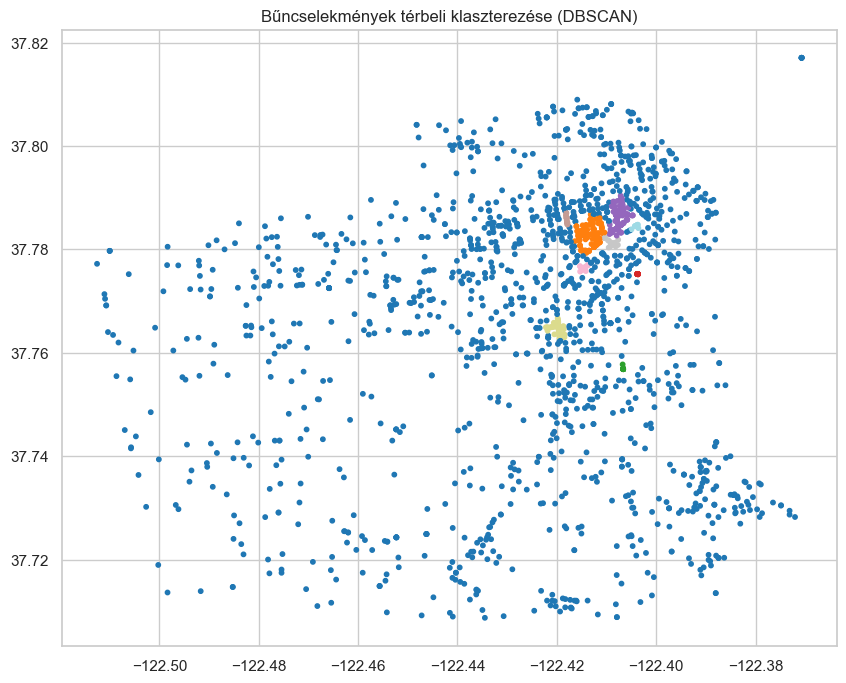

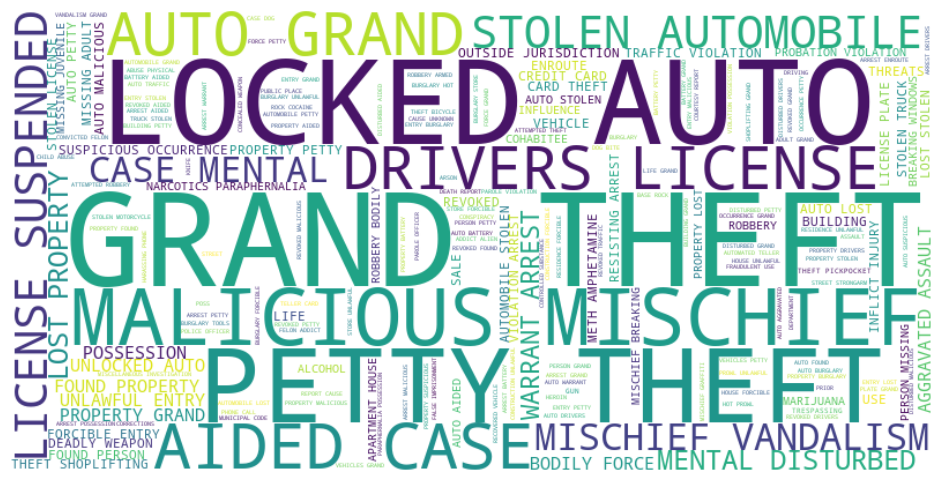

In [7]:
coords = df[['X', 'Y']].sample(min(2000, len(df)))
db = DBSCAN(eps=0.001, min_samples=10).fit(coords)
coords['Cluster'] = db.labels_
plt.figure(figsize=(10, 8))
plt.scatter(coords['X'], coords['Y'], c=coords['Cluster'], cmap='tab20', s=10)
plt.title('Bűncselekmények térbeli klaszterezése (DBSCAN)')
plt.show()

text = " ".join(df['Descript'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## 2. fázis: Prediktív modellezés (XGBoost)
Ebben a verzióban RandomForest helyett XGBoost modellt használunk, amely iteratív módon (tanítási körökön keresztül) tanul.

Tanítás megkezdése...


Tanítás befejezve.
                             precision    recall  f1-score   support

                      ARSON       0.00      0.00      0.00        12
                    ASSAULT       0.19      0.07      0.10       504
                   BURGLARY       0.21      0.04      0.07       251
         DISORDERLY CONDUCT       0.00      0.00      0.00        14
DRIVING UNDER THE INFLUENCE       0.00      0.00      0.00        19
              DRUG/NARCOTIC       0.36      0.25      0.29       258
                DRUNKENNESS       0.00      0.00      0.00        28
               EMBEZZLEMENT       0.00      0.00      0.00         4
     FORGERY/COUNTERFEITING       0.00      0.00      0.00        18
                      FRAUD       0.25      0.01      0.02       115
                 KIDNAPPING       0.00      0.00      0.00        26
              LARCENY/THEFT       0.34      0.82      0.48      1641
                LIQUOR LAWS       0.00      0.00      0.00         7
             M

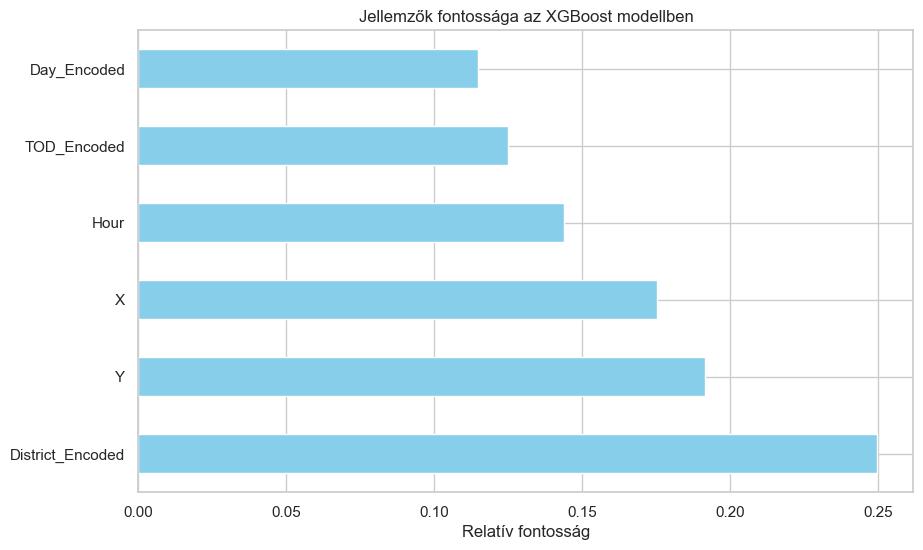

In [8]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

# 1. Csak azokat a sorokat tartjuk meg, ahol a Category nem ritka (legalább 10 előfordulás)
# Ez segít elkerülni, hogy a train/test split során eltűnjenek kategóriák.
cat_counts = df['Category'].value_counts()
valid_cats = cat_counts[cat_counts >= 10].index
df_filtered = df[df['Category'].isin(valid_cats)].copy()

# 2. Adatok kódolása
le_cat = LabelEncoder()
le_day = LabelEncoder()
le_dist = LabelEncoder()
le_tod = LabelEncoder()

# Category kódolása (XGBoost 0..N-ig várja)
y = le_cat.fit_transform(df_filtered['Category'])

df_filtered['Day_Encoded'] = le_day.fit_transform(df_filtered['DayOfWeek'])
df_filtered['District_Encoded'] = le_dist.fit_transform(df_filtered['PdDistrict'])
df_filtered['TOD_Encoded'] = le_tod.fit_transform(df_filtered['Time_of_Day'])

features = ['Day_Encoded', 'District_Encoded', 'Hour', 'X', 'Y', 'TOD_Encoded']
X = df_filtered[features]

# 3. Split - a 'stratify=y' biztosítja, hogy minden kategória bekerüljön mindkét halmazba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. XGBoost modell létrehozása
clf = xgb.XGBClassifier(
    n_estimators=100, 
    max_depth=6, 
    learning_rate=0.1, 
    random_state=42,
    objective='multi:softprob',
    eval_metric='mlogloss'
)

# Tanítás
print("Tanítás megkezdése...")
clf.fit(X_train, y_train)
print("Tanítás befejezve.")

# Predikció és kiértékelés
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le_cat.classes_, zero_division=0))

# ÚJ: Jellemzők fontosságának vizualizációja
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(clf.feature_importances_, index=features)
feat_importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title('Jellemzők fontossága az XGBoost modellben')
plt.xlabel('Relatív fontosság')
plt.show()